In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
data = {
    'Hours': [2, 3, 4, 4, 5, 5, 6, 6, 7, 8,
              2, 3, 4, 5, 6, 7, 8, 9, 3, 7],

    'Attendance': [50, 55, 60, 65, 70, 75, 75, 80, 85, 90,
                   45, 50, 58, 68, 72, 78, 88, 92, 52, 82],

    'Result': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
               0, 0, 0, 1, 1, 1, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

df

,Hours,Attendance,Result
0,2,50,0
1,3,55,0
2,4,60,0
3,4,65,0
4,5,70,1
5,5,75,1
6,6,75,1
7,6,80,1
8,7,85,1
9,8,90,1


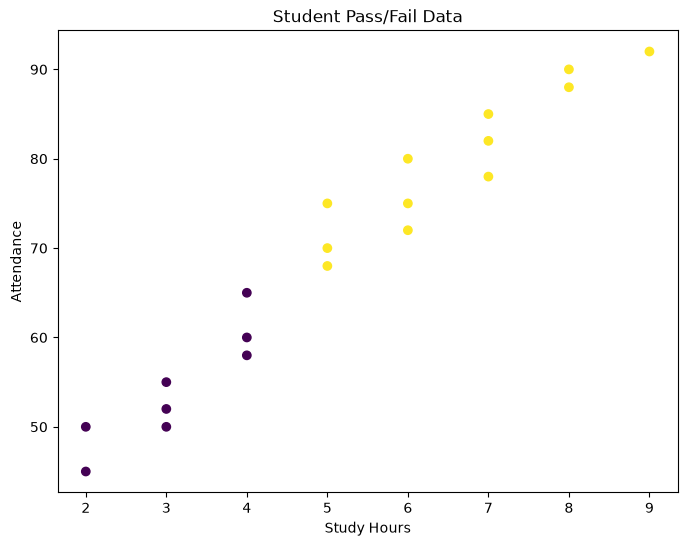

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Hours'],
    df['Attendance'],
    c=df['Result'],
    marker='o'
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Student Pass/Fail Data")

plt.show()

In [5]:
X = df[['Hours', 'Attendance']]
y = df['Result']

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   Hours  Attendance
0      2          50
1      3          55
2      4          60
3      4          65
4      5          70

y:
0    0
1    0
2    0
3    0
4    1
Name: Result, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 2)
Testing data: (4, 2)


In [7]:
log_reg = LogisticRegression()

log_reg.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
y_pred = log_reg.predict(X_test)

print("Actual:")
print(y_test.values)

print("\nPredicted:")
print(y_pred)

Actual:
[0 0 1 1]

Predicted:
[0 1 1 1]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 2)
Testing data: (4, 2)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 2)
Testing data: (4, 2)


In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 1]
 [0 2]]


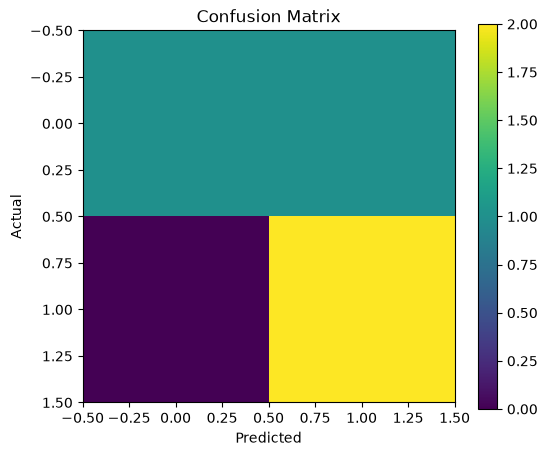

In [12]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [14]:
result_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

result_df

,Actual,Predicted
0,0,0
1,0,1
2,1,1
3,1,1


In [15]:
result_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

result_df

,Actual,Predicted
0,0,0
1,0,1
2,1,1
3,1,1


In [16]:
new_student = pd.DataFrame({
    'Hours': [5.5],
    'Attendance': [72]
})

prediction = log_reg.predict(new_student)
probability = log_reg.predict_proba(new_student)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: 1
Probability: [0.01153045 0.98846955]


In [17]:
if prediction[0] == 1:
    print("Student will likely PASS ✅")
else:
    print("Student will likely FAIL ❌")

Student will likely PASS ✅


In [18]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(log_reg, f)